# **신용카드 고객 군집화 (Credit Card Customer Clustering)**
---

**<분석 목적>**     
 : 고객 데이터를 군집화하여 사용 패턴을 이해하고, 이를 토대로 맞춤형 마케팅 전략과 신상품 개발

## 1. 데이터 탐색

### (1) 데이터 로드

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [4]:
card = pd.read_csv("CreditCardDataset.csv")
card.head()

,CUST_ID,BALANCE,BALANCE_FREQU,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQ,ONEOFF_PURCHASES_FREQ,PURCHASES_INSTALLMENTS_FREQ,CASH_ADVANCE_FREQ,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
card.isnull().sum()

CUST_ID                          0
BALANCE                          0
BALANCE_FREQU                    0
PURCHASES                        0
ONEOFF_PURCHASES                 0
INSTALLMENTS_PURCHASES           0
CASH_ADVANCE                     0
PURCHASES_FREQ                   0
ONEOFF_PURCHASES_FREQ            0
PURCHASES_INSTALLMENTS_FREQ      0
CASH_ADVANCE_FREQ                0
CASH_ADVANCE_TRX                 0
PURCHASES_TRX                    0
CREDIT_LIMIT                     1
PAYMENTS                         0
MINIMUM_PAYMENTS               313
PRC_FULL_PAYMENT                 0
TENURE                           0
dtype: int64

In [6]:
card.dtypes

CUST_ID                         object
BALANCE                        float64
BALANCE_FREQU                  float64
PURCHASES                      float64
ONEOFF_PURCHASES               float64
INSTALLMENTS_PURCHASES         float64
CASH_ADVANCE                   float64
PURCHASES_FREQ                 float64
ONEOFF_PURCHASES_FREQ          float64
PURCHASES_INSTALLMENTS_FREQ    float64
CASH_ADVANCE_FREQ              float64
CASH_ADVANCE_TRX                 int64
PURCHASES_TRX                    int64
CREDIT_LIMIT                   float64
PAYMENTS                       float64
MINIMUM_PAYMENTS               float64
PRC_FULL_PAYMENT               float64
TENURE                           int64
dtype: object

In [7]:
card.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQU,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQ,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQ,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQ,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQ,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


### (2) EDA 

**금액형 변수(거래 규모):**             
BALANCE, PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, CASH_ADVANCE, PAYMENTS, MINIMUM_PAYMENTS, CREDIT_LIMIT
           
           
**빈도형 변수(행동 패턴):**
BALANCE_FREQUENCY, PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_FREQUENCY


In [8]:
#질적변수 제거
card=card.drop(columns="CUST_ID")

In [9]:
card['TENURE'].value_counts(normalize=True) * 100
#대부분 12이므로 구분력 약함->제거

TENURE
12    84.737430
11     4.078212
10     2.636872
6      2.279330
8      2.189944
7      2.122905
9      1.955307
Name: proportion, dtype: float64

In [10]:
card = card.drop(columns=["TENURE"])

In [11]:
card = card.dropna(subset=["CREDIT_LIMIT"])

In [12]:
card[(card["PAYMENTS"] == 0) & (card["MINIMUM_PAYMENTS"].isna())]
# 결측치 313개 중 240개는 결제 자체 없는 고객(비활성화고객)

,BALANCE,BALANCE_FREQU,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQ,ONEOFF_PURCHASES_FREQ,PURCHASES_INSTALLMENTS_FREQ,CASH_ADVANCE_FREQ,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.0,NaN,0.0
45,2242.311686,1.000000,437.00,97.00,340.0,184.648692,0.333333,0.083333,0.333333,0.166667,2,5,2400.0,0.0,NaN,0.0
47,3910.111237,1.000000,0.00,0.00,0.0,1980.873201,0.000000,0.000000,0.000000,0.500000,7,0,4200.0,0.0,NaN,0.0
55,1311.995984,1.000000,1283.90,1283.90,0.0,0.000000,0.250000,0.250000,0.000000,0.000000,0,6,6000.0,0.0,NaN,0.0
56,3625.218146,1.000000,313.27,313.27,0.0,668.468743,0.250000,0.250000,0.000000,0.416667,5,4,4000.0,0.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8854,3.833185,0.125000,45.00,45.00,0.0,0.000000,0.125000,0.125000,0.000000,0.000000,0,1,500.0,0.0,NaN,0.0
8919,14.524779,0.333333,152.00,152.00,0.0,0.000000,0.333333,0.333333,0.000000,0.000000,0,2,1500.0,0.0,NaN,0.0
8929,371.527312,0.333333,0.00,0.00,0.0,1465.407927,0.000000,0.000000,0.000000,0.166667,5,0,1500.0,0.0,NaN,0.0
8935,183.817004,1.000000,465.90,0.00,465.9,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1500.0,0.0,NaN,0.0


In [13]:
# 비활성 고객 (결제 없음 → 0으로 채움)
card.loc[(card["PAYMENTS"] == 0) & (card["MINIMUM_PAYMENTS"].isna()), "MINIMUM_PAYMENTS"] = 0

# 나머지 73명 제거
card = card.dropna(subset=["MINIMUM_PAYMENTS"])

print("남은 결측치 수:\n", card.isnull().sum())
print("최종 데이터 크기:", card.shape)


남은 결측치 수:
 BALANCE                        0
BALANCE_FREQU                  0
PURCHASES                      0
ONEOFF_PURCHASES               0
INSTALLMENTS_PURCHASES         0
CASH_ADVANCE                   0
PURCHASES_FREQ                 0
ONEOFF_PURCHASES_FREQ          0
PURCHASES_INSTALLMENTS_FREQ    0
CASH_ADVANCE_FREQ              0
CASH_ADVANCE_TRX               0
PURCHASES_TRX                  0
CREDIT_LIMIT                   0
PAYMENTS                       0
MINIMUM_PAYMENTS               0
PRC_FULL_PAYMENT               0
dtype: int64
최종 데이터 크기: (8876, 16)


In [14]:
card.isna().sum()

BALANCE                        0
BALANCE_FREQU                  0
PURCHASES                      0
ONEOFF_PURCHASES               0
INSTALLMENTS_PURCHASES         0
CASH_ADVANCE                   0
PURCHASES_FREQ                 0
ONEOFF_PURCHASES_FREQ          0
PURCHASES_INSTALLMENTS_FREQ    0
CASH_ADVANCE_FREQ              0
CASH_ADVANCE_TRX               0
PURCHASES_TRX                  0
CREDIT_LIMIT                   0
PAYMENTS                       0
MINIMUM_PAYMENTS               0
PRC_FULL_PAYMENT               0
dtype: int64

In [15]:
card = card.drop(columns=["BALANCE_FREQU","CASH_ADVANCE_TRX","PURCHASES_TRX"])
#단순 수치형 활동량 제외

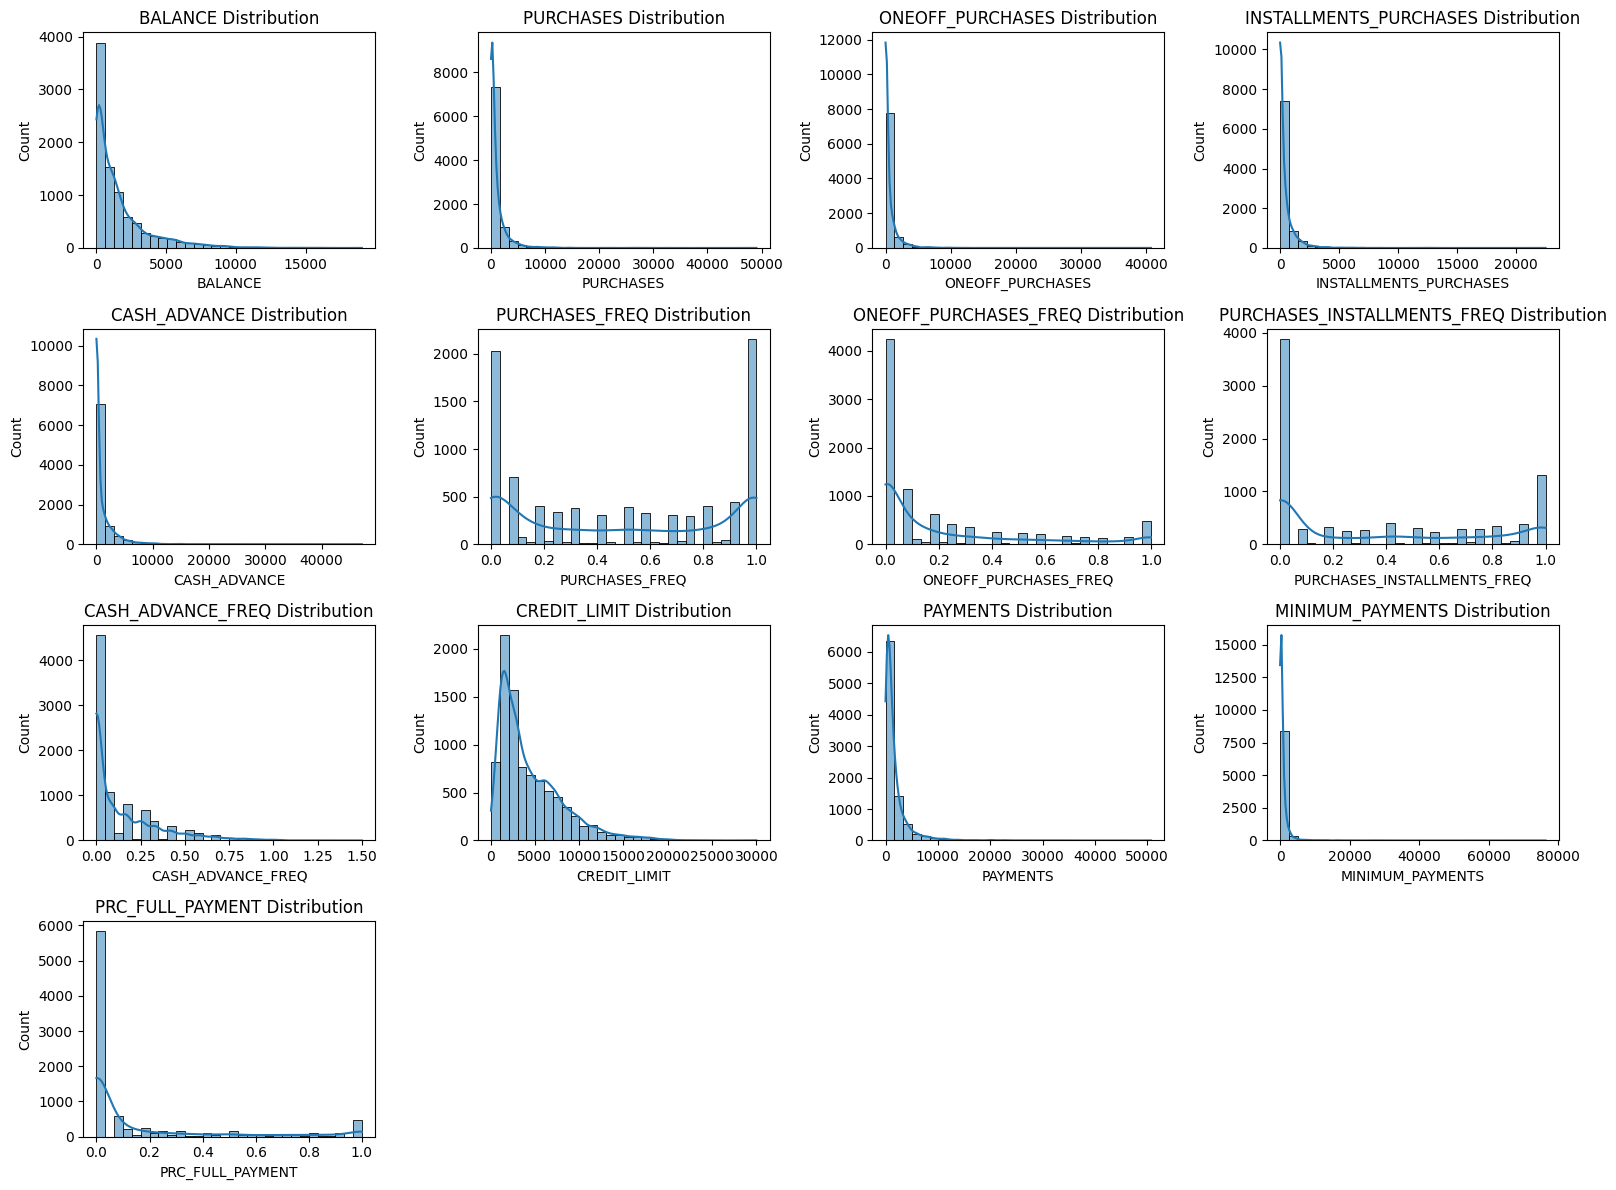

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 전체 변수 (df의 모든 컬럼)
all_vars = card.columns
n_vars = len(all_vars)

# subplot 크기 설정
n_cols = 4
n_rows = -(-n_vars // n_cols)

plt.figure(figsize=(4 * n_cols, 3 * n_rows))

for i, var in enumerate(all_vars, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(card[var], kde=True, bins=30)
    plt.title(f'{var} Distribution')

plt.tight_layout()
plt.show()


In [17]:
import numpy as np

# 로그변환 적용 (log1p = log(1+x), 0 값도 안전하게 변환)
log_cols = [
    'BALANCE',
    'PURCHASES',
    'CASH_ADVANCE',
    'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES', 
    'CREDIT_LIMIT',
    'PAYMENTS',
    'MINIMUM_PAYMENTS',
    
]

for col in log_cols:
    card[col] = np.log1p(card[col])

In [18]:
# logit 적용 전: 비율형 변수(0~1)에서 1 초과값 제거
freq_cols = [
    
    'PURCHASES_FREQ',
    'ONEOFF_PURCHASES_FREQ',
    'PURCHASES_INSTALLMENTS_FREQ',
    'CASH_ADVANCE_FREQ',
    'PRC_FULL_PAYMENT'
]

# 1보다 큰 값이 하나라도 포함된 행 찾기
mask = (card[freq_cols] > 1).any(axis=1)
n_outliers = mask.sum()

print(f"1을 초과하는 비율값을 가진 행 수: {n_outliers}")

# 해당 행 제거
card = card[~mask].reset_index(drop=True)

print(f"✅ 이상치 제거 후 데이터 shape: {card.shape}")


1을 초과하는 비율값을 가진 행 수: 8
✅ 이상치 제거 후 데이터 shape: (8868, 13)


In [19]:
import numpy as np
from scipy.special import logit

# ✅ logit 변환 적용할 비율형(행동패턴형) 변수들
logit_cols = [
    
    'PURCHASES_FREQ',
    'ONEOFF_PURCHASES_FREQ',
    'PURCHASES_INSTALLMENTS_FREQ',
    'CASH_ADVANCE_FREQ',
    'PRC_FULL_PAYMENT'
]

# ✅ 0과 1 극단값을 피하기 위한 작은 epsilon 설정
eps = 1e-5  


for col in logit_cols:
    # ① 0~1 범위 밖 값 있을 경우 경고 출력
    if (card[col] < 0).any() or (card[col] > 1).any():
        print(f"[경고] {col}에 0~1 범위를 벗어난 값이 있습니다. → 클립하여 변환합니다.")

    # ② 0,1 값 클립 후 logit 적용
    card[col] = logit(card[col].clip(eps, 1 - eps))


card[logit_cols].head()


,PURCHASES_FREQ,ONEOFF_PURCHASES_FREQ,PURCHASES_INSTALLMENTS_FREQ,CASH_ADVANCE_FREQ,PRC_FULL_PAYMENT
0,-1.609436,-11.512915,-2.397900,-11.512915,-11.512915
1,-11.512915,-11.512915,-11.512915,-1.098612,-1.252764
2,11.512915,11.512915,-11.512915,-11.512915,-11.512915
3,-2.397900,-2.397900,-11.512915,-2.397900,-11.512915
4,-2.397900,-2.397900,-11.512915,-11.512915,-11.512915


In [20]:
drop_cols = ['PRC_FULL_PAYMENT']

card = card.drop(columns=drop_cols)
#여전히 치우친분포

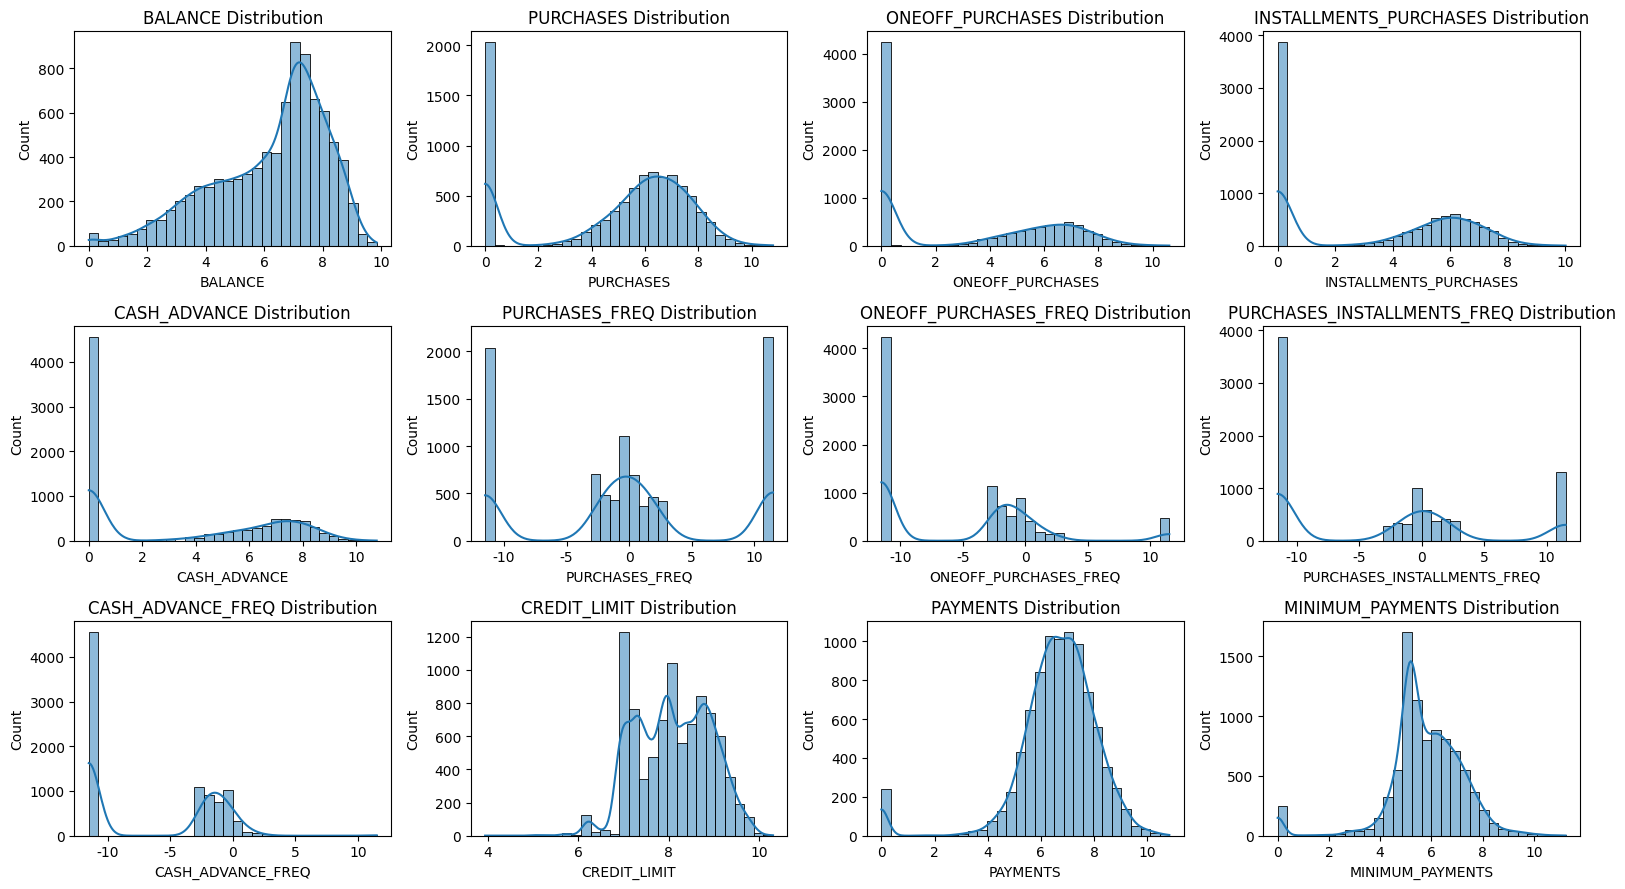

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 전체 변수 (df의 모든 컬럼)
all_vars = card.columns
n_vars = len(all_vars)

# subplot 크기 설정
n_cols = 4
n_rows = -(-n_vars // n_cols)

plt.figure(figsize=(4 * n_cols, 3 * n_rows))

for i, var in enumerate(all_vars, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(card[var], kde=True, bins=30)
    plt.title(f'{var} Distribution')

plt.tight_layout()
plt.show()


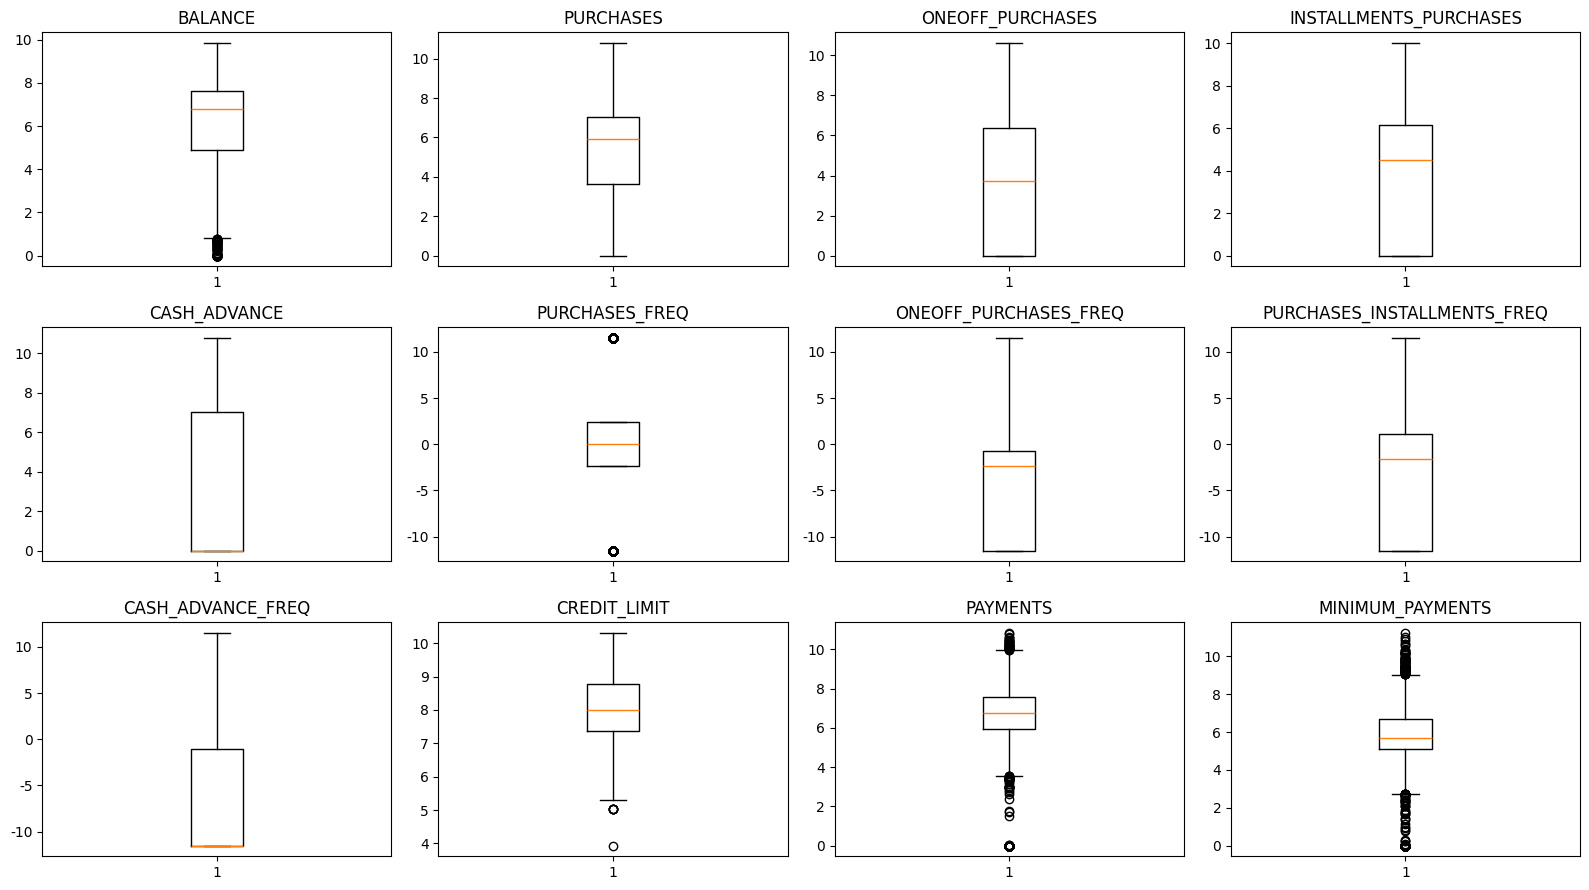

In [22]:
plt.figure(figsize=(4 * n_cols, 3 * n_rows))

for i, var in enumerate(all_vars, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(card[var].values, vert=True)
   
    plt.title(var)

plt.tight_layout()
plt.show()


### (3) 스케일링

In [23]:
scaler = StandardScaler()
scaled_df = scaler.fit_transform(card)
scaled_df = pd.DataFrame(scaled_df, columns=card.columns)

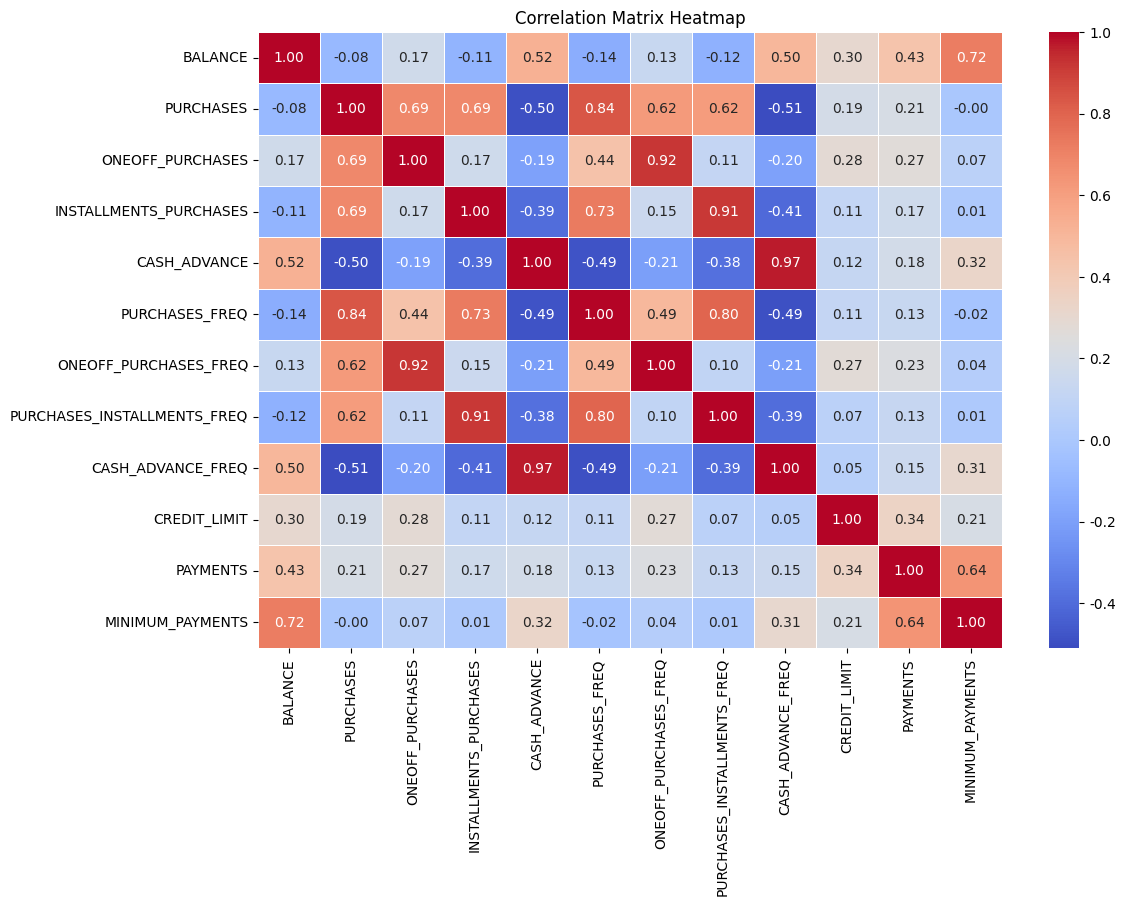

In [24]:
# 히트맵으로 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(scaled_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [25]:
from sklearn.decomposition import PCA

# ✅ 1️⃣ PCA 그룹 정의
group1 = scaled_df[['PURCHASES', 'PURCHASES_FREQ']]
group2 = scaled_df[['ONEOFF_PURCHASES', 'ONEOFF_PURCHASES_FREQ']]
group3 = scaled_df[['INSTALLMENTS_PURCHASES', 'PURCHASES_INSTALLMENTS_FREQ']]
group4 = scaled_df[['CASH_ADVANCE', 'CASH_ADVANCE_FREQ']]

# ✅ 2️⃣ 각 그룹별 PCA 수행 (주성분 1개만 추출)

pca1 = PCA(n_components=1)
scaled_df['PC_Purchases'] = pca1.fit_transform(group1)

pca2 = PCA(n_components=1)
scaled_df['PC_OneOff'] = pca2.fit_transform(group2)

pca3 = PCA(n_components=1)
scaled_df['PC_Installments'] = pca3.fit_transform(group3)

pca4 = PCA(n_components=1)
scaled_df['PC_CashAdvance'] = pca4.fit_transform(group4)

# ✅ 3️⃣ 사용된 원본 변수 삭제 (BALANCE_FREQU 제외)
scaled_df = scaled_df.drop([
    'PURCHASES', 'PURCHASES_FREQ',
    'ONEOFF_PURCHASES', 'ONEOFF_PURCHASES_FREQ',
    'INSTALLMENTS_PURCHASES', 'PURCHASES_INSTALLMENTS_FREQ',
    'CASH_ADVANCE', 'CASH_ADVANCE_FREQ'
], axis=1)

# ✅ 4️⃣ 결과 확인
print(scaled_df.shape)
scaled_df.head()


(8868, 8)


,BALANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PC_Purchases,PC_OneOff,PC_Installments,PC_CashAdvance
0,-1.262406,-1.447855,-0.828406,-0.538027,-0.229597,-1.363229,0.35453,-1.335782
1,0.954397,0.923075,1.061475,0.802215,-2.211562,-1.363229,-1.47591,1.790991
2,0.826867,1.007162,-0.123086,0.449210,1.436154,2.554438,-1.47591,-1.335782
3,0.620699,1.007162,-4.166561,-3.797765,0.364566,1.206294,-1.47591,0.936149
4,0.257025,-1.225816,-0.068755,-0.169421,-0.719186,0.231160,-1.47591,-1.335782


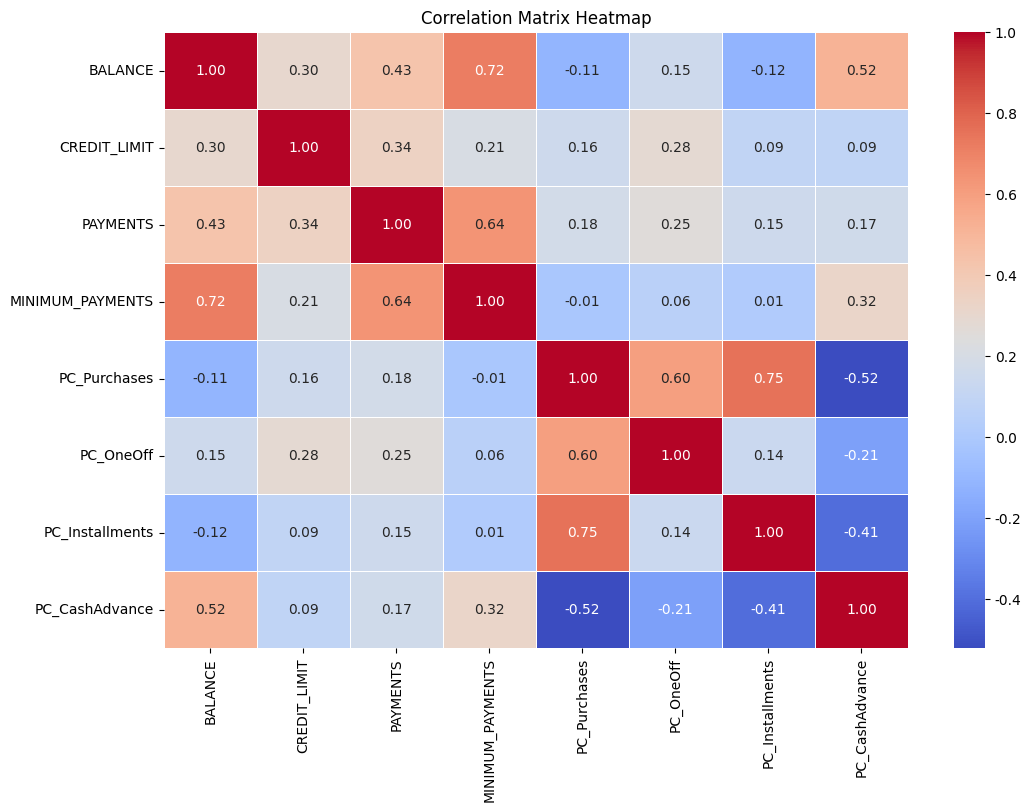

In [25]:
# 히트맵으로 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(scaled_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

---

## 2. 모델 구현

### (1) K-means

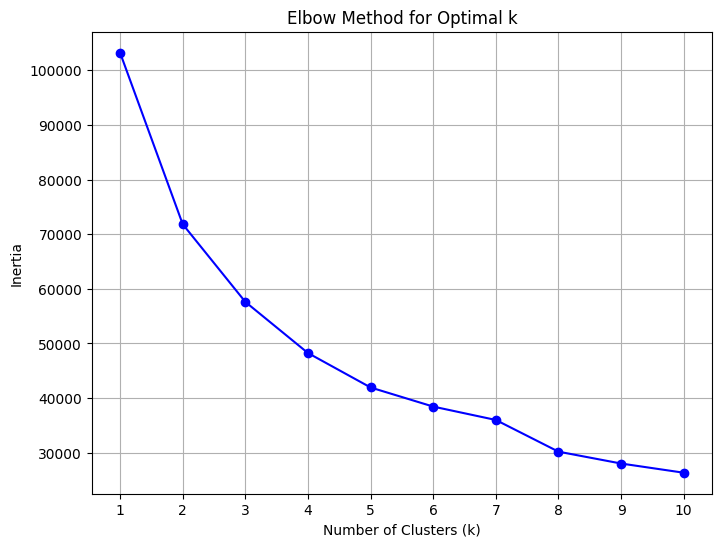

In [26]:
# 엘보우 기법
inertia = []
for k in range(1, 11):  # 클러스터 개수를 1부터 10까지 시도
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

# 엘보우 그래프 시각화
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='-', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [32]:
for i in range(5, 16):
    kmeans = KMeans(
        n_clusters=5,
        random_state=42,
        n_init=i,
        max_iter=300  # max_iter 변경 가능
    )
    kmeans_labels = kmeans.fit_predict(scaled_df)

    # 실루엣 계수 출력
    kmeans_silhouette = silhouette_score(scaled_df, kmeans_labels)
    print(f"K-Means (n_init={i}, max_iter=300) Silhouette Score: {kmeans_silhouette:.4f}")

K-Means (n_init=5, max_iter=300) Silhouette Score: 0.3286
K-Means (n_init=6, max_iter=300) Silhouette Score: 0.3286
K-Means (n_init=7, max_iter=300) Silhouette Score: 0.3286
K-Means (n_init=8, max_iter=300) Silhouette Score: 0.3286
K-Means (n_init=9, max_iter=300) Silhouette Score: 0.3286
K-Means (n_init=10, max_iter=300) Silhouette Score: 0.3286
K-Means (n_init=11, max_iter=300) Silhouette Score: 0.3286
K-Means (n_init=12, max_iter=300) Silhouette Score: 0.3286
K-Means (n_init=13, max_iter=300) Silhouette Score: 0.3286
K-Means (n_init=14, max_iter=300) Silhouette Score: 0.3286
K-Means (n_init=15, max_iter=300) Silhouette Score: 0.3286


In [33]:
# 시각화

num_cols = scaled_df.select_dtypes(include=[np.number]).columns
X_full = scaled_df[num_cols].dropna().values

# 2차, 3차 시각화를 위한 PCA
pca2 = PCA(n_components=2, random_state=42)
X2 = pca2.fit_transform(X_full)

pca3 = PCA(n_components=3, random_state=42)
X3 = pca3.fit_transform(X_full)


In [34]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 2D plot with colormap & colorbar
def plot_2d(points, labels, title):
    plt.figure(figsize=(7,6))
    scatter = plt.scatter(points[:,0], points[:,1], c=labels, cmap='viridis', alpha=0.8)
    plt.colorbar(scatter, label='Cluster')
    plt.title(title)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.tight_layout()
    plt.show()

# 3D plot with colormap & colorbar
def plot_3d(points, labels, title):
    fig = plt.figure(figsize=(9,7))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(points[:,0], points[:,1], points[:,2], c=labels, cmap='viridis', alpha=0.8)
    fig.colorbar(scatter, ax=ax, label='Cluster')
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    plt.tight_layout()
    plt.show()

In [35]:
fit_on_full = False

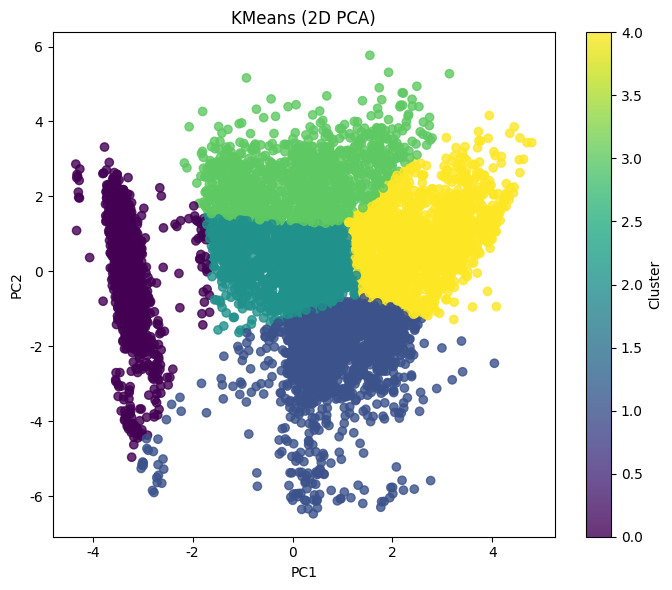

In [36]:
if fit_on_full:
    km2 = KMeans(n_clusters=5, random_state=42).fit(X_full)
    labels_km2 = km2.labels_
    pts2 = X2 # project for display
else:
    km2 = KMeans(n_clusters=5, random_state=42).fit(X2)
    labels_km2 = km2.labels_
    pts2 = X2


plot_2d(pts2, labels_km2, 'KMeans (2D PCA)')

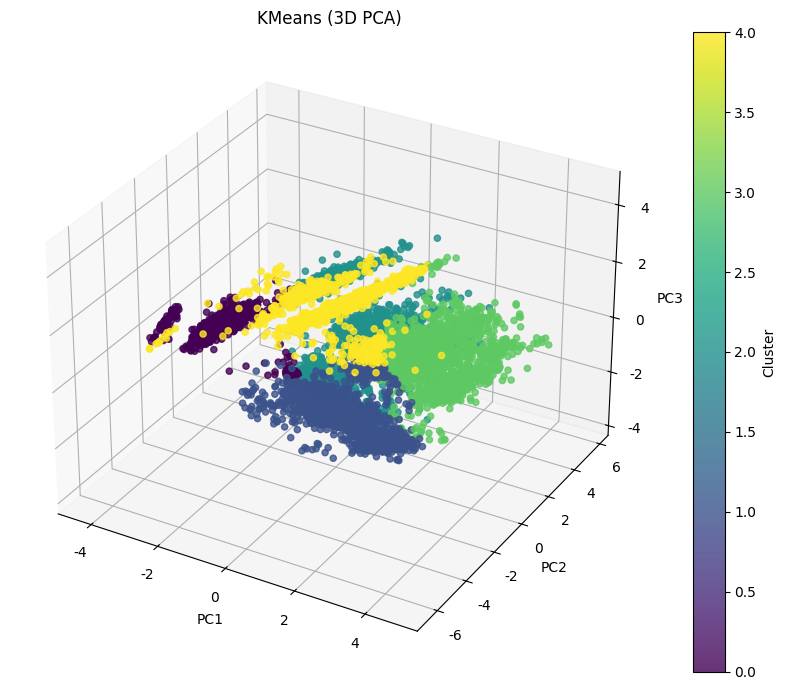

In [37]:
if fit_on_full:
    km3 = KMeans(n_clusters=5, random_state=42).fit(X_full)
    labels_km3 = km3.labels_
    pts3 = X3
else:
    km3 = KMeans(n_clusters=5, random_state=42).fit(X3)
    labels_km3 = km3.labels_
    pts3 = X3


plot_3d(pts3, labels_km3, 'KMeans (3D PCA)') #과제할때 시각화와 실루엣 같이 보기!

---

### (2) GMM

In [38]:
# AIC, BIC 계산
aic_scores = []
bic_scores = []

for i in range(2, 11):
    gmm = GaussianMixture(n_components=i, random_state=42)
    gmm.fit(scaled_df)
    
    # AIC, BIC 계산
    aic_scores.append(gmm.aic(scaled_df))
    bic_scores.append(gmm.bic(scaled_df))

# AIC, BIC 출력
for n, aic, bic in zip(range(2,11), aic_scores, bic_scores):
    print(f"Clusters: {n}, AIC: {aic:.2f}, BIC: {bic:.2f}")

Clusters: 2, AIC: 119401.18, BIC: 120032.20
Clusters: 3, AIC: 70142.97, BIC: 71093.06
Clusters: 4, AIC: 19527.21, BIC: 20796.35
Clusters: 5, AIC: -25498.30, BIC: -23910.09
Clusters: 6, AIC: -29751.25, BIC: -27843.99
Clusters: 7, AIC: -15750.23, BIC: -13523.90
Clusters: 8, AIC: -54308.64, BIC: -51763.25
Clusters: 9, AIC: -61871.21, BIC: -59006.77
Clusters: 10, AIC: -68996.80, BIC: -65813.30


In [39]:
# GMM 클러스터링
for i in range(2, 11) :
    gmm = GaussianMixture(n_components = i, random_state=42)
    gmm_labels = gmm.fit_predict(scaled_df)

    # 실루엣 계수 출력
    gmm_silhouette = silhouette_score(scaled_df, gmm_labels)
    print(f"GMM {i} components Silhouette Score: {gmm_silhouette:.4f}")

GMM 2 components Silhouette Score: 0.3004
GMM 3 components Silhouette Score: 0.2498
GMM 4 components Silhouette Score: 0.2863
GMM 5 components Silhouette Score: 0.3160
GMM 6 components Silhouette Score: 0.3169
GMM 7 components Silhouette Score: 0.2689
GMM 8 components Silhouette Score: 0.2868
GMM 9 components Silhouette Score: 0.2966
GMM 10 components Silhouette Score: 0.2158


In [40]:
fit_on_full = False

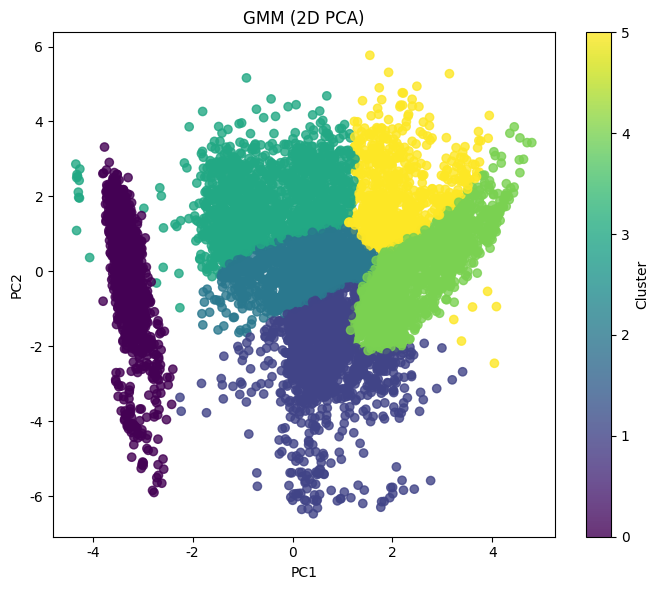

In [41]:
if fit_on_full:
    gmm2 = GaussianMixture(n_components=6, random_state=42).fit(X_full)
    labels_gmm2 = gmm2.predict(X_full)
    pts2 = X2
else:
    gmm2 = GaussianMixture(n_components=6, random_state=42).fit(X2)
    labels_gmm2 = gmm2.predict(X2)
    pts2 = X2


plot_2d(pts2, labels_gmm2, 'GMM (2D PCA)')

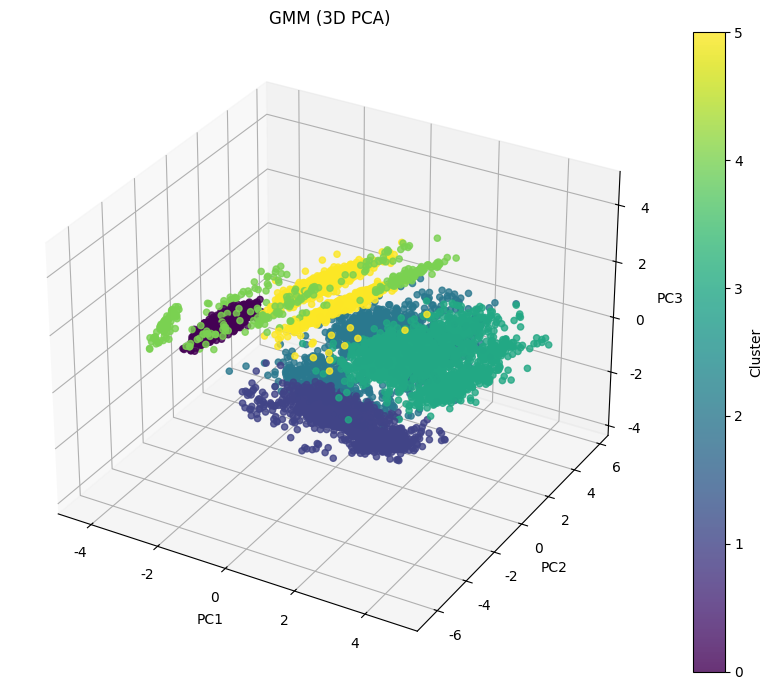

In [42]:
if fit_on_full:
    gmm3 = GaussianMixture(n_components=6, random_state=42).fit(X_full)
    labels_gmm3 = gmm3.predict(X_full)
    pts3 = X3
else:
    gmm3 = GaussianMixture(n_components=6, random_state=42).fit(X3)
    labels_gmm3 = gmm3.predict(X3)
    pts3 = X3


plot_3d(pts3, labels_gmm3, 'GMM (3D PCA)')

---

### (3) 계층적 클러스터링

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram

In [27]:
X = scaled_df.values  
# 공통 하이퍼파라미터
LINKAGE = 'average'       
METRIC  = 'euclidean'     # bc 속도/안정성 측면도 유리
K_RANGE = range(2, 8)     

In [28]:
def cutoff_for_k(Z, k: int):
    
    return Z[-(k-1), 2]
    
Z = linkage(X, method=LINKAGE, metric=METRIC)

[A] AgglomerativeClustering: n_clusters sweep

k= 2 | silhouette= 0.396 | DBI= 1.038 (낮을수록 좋음) | CHI= 785.4 (높을수록 좋음)
k= 3 | silhouette= 0.261 | DBI= 0.974 (낮을수록 좋음) | CHI= 399.3 (높을수록 좋음)
k= 4 | silhouette= 0.166 | DBI= 0.896 (낮을수록 좋음) | CHI= 266.9 (높을수록 좋음)
k= 5 | silhouette= 0.163 | DBI= 0.885 (낮을수록 좋음) | CHI= 202.5 (높을수록 좋음)
k= 6 | silhouette= 0.231 | DBI= 0.873 (낮을수록 좋음) | CHI= 1004.3 (높을수록 좋음)
k= 7 | silhouette= 0.198 | DBI= 1.004 (낮을수록 좋음) | CHI= 838.1 (높을수록 좋음)

📍[A] DBI 기준 k* = 6 (DBI=0.873, sil=0.231, CHI=1004.3)


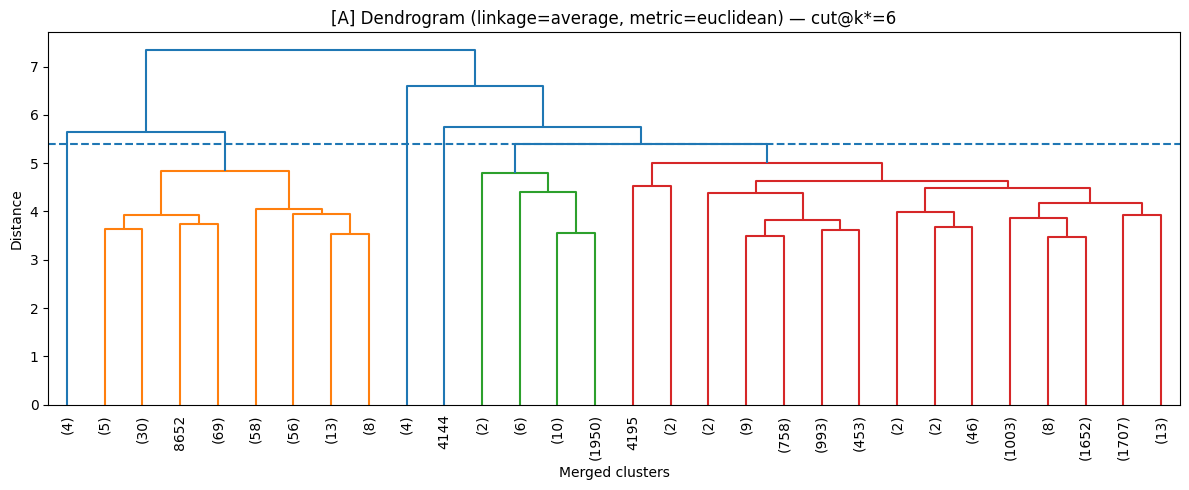

[A] k* 재적용 → silhouette=0.231, DBI=0.873, CHI=1004.3


In [29]:
results = []  # (k, sil, dbi, chi)
print("[A] AgglomerativeClustering: n_clusters sweep\n")
for k in K_RANGE:
    model = AgglomerativeClustering(n_clusters=k, linkage=LINKAGE, metric=METRIC)
    labels = model.fit_predict(X)

    sil = silhouette_score(X, labels)
    dbi = davies_bouldin_score(X, labels)
    chi = calinski_harabasz_score(X, labels)
    results.append((k, sil, dbi, chi))

    print(f"k={k:>2} | silhouette={sil: .3f} | DBI={dbi: .3f} (낮을수록 좋음) | CHI={chi: .1f} (높을수록 좋음)")

# 최소DBI 선택(=최대 CHI) bc 실루엣 점수로 하면 k=2가 됨.
k_star_A, sil_star_A, dbi_star_A, chi_star_A = min(results, key=lambda r: r[2])
print(f"\n📍[A] DBI 기준 k* = {k_star_A} (DBI={dbi_star_A:.3f}, sil={sil_star_A:.3f}, CHI={chi_star_A:.1f})")

# 덴드로그램에서 k* 컷오프 표시
cut_for_k_A = cutoff_for_k(Z, k_star_A)
plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., color_threshold=cut_for_k_A)
plt.title(f"[A] Dendrogram (linkage={LINKAGE}, metric={METRIC}) — cut@k*={k_star_A}")
plt.xlabel("Merged clusters")
plt.ylabel("Distance")
plt.axhline(y=cut_for_k_A, linestyle='--')
plt.tight_layout()
plt.show()

# k*로 다시 학습하여 최종 지표 확인
try:
    final_A = AgglomerativeClustering(n_clusters=k_star_A, linkage=LINKAGE, metric=METRIC)
except TypeError:
    final_A = AgglomerativeClustering(n_clusters=k_star_A, linkage=LINKAGE, affinity=METRIC)

labels_A = final_A.fit_predict(X)
sil_A = silhouette_score(X, labels_A)
dbi_A = davies_bouldin_score(X, labels_A)
chi_A = calinski_harabasz_score(X, labels_A)
print(f"[A] k* 재적용 → silhouette={sil_A:.3f}, DBI={dbi_A:.3f}, CHI={chi_A:.1f}")


---

## 3. 모델 평가 및 군집별 특징 조사


- K-means: k=5일 때, 실루엣 점수 0.328로 높음              
(실루엣 점수가 가장 높아 가장 명확한 군집 구조를 형성함)   
                            
- GMM: k=6일 때, 0.317로 높음           
 (복잡한 형태의 분포를 더 잘 설명할 수 있음. 하지만 데이터가 명확히 분리되지 않아 K-means보다 점수가 약간 낮음) 
                    
- 계층적: 실루엣 점수 0.231             
(데이터 수가 많거나 군집 간 경계가 불명확할 경우 성능이 떨어질 수 있음.
실루엣 점수 비교적 낮음)




### (1) K-means

In [60]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# k=5로 최종 모델 확정
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10, max_iter=300)
card['Cluster'] = kmeans.fit_predict(scaled_df)

# 군집별 개수 확인
print(card['Cluster'].value_counts())


Cluster
0    2662
2    2095
3    2003
4    1843
1     265
Name: count, dtype: int64


In [61]:
# 각 변수의 군집별 평균값
cluster_summary = card.groupby('Cluster').mean().round(3)

# 보기 좋게 전치
cluster_summary = cluster_summary.T.sort_index()
display(cluster_summary)


Cluster,0,1,2,3,4
BALANCE,5.987,3.807,7.455,7.107,4.463
CASH_ADVANCE,0.014,2.876,6.976,6.855,0.240
CASH_ADVANCE_FREQ,-11.478,-7.240,-1.013,-1.104,-11.082
CREDIT_LIMIT,8.298,7.990,8.286,7.984,7.728
Cluster_GMM,3.255,1.774,0.705,2.954,1.061
INSTALLMENTS_PURCHASES,3.937,1.915,3.884,0.037,5.722
MINIMUM_PAYMENTS,5.654,0.215,6.579,6.229,5.277
ONEOFF_PURCHASES,6.383,2.373,5.041,0.034,0.156
ONEOFF_PURCHASES_FREQ,0.893,-6.632,-2.192,-11.389,-11.129
PAYMENTS,7.002,0.326,7.280,6.769,6.112


In [62]:
# scaled_df에 군집 정보 추가
scaled_df_clustered = scaled_df.copy()
scaled_df_clustered['Cluster'] = card['Cluster']

feature_importance = {}
for col in scaled_df.columns:  # scaled_df에 실제 존재하는 컬럼만 반복
    overall_mean = scaled_df_clustered[col].mean()
    between_var = sum([
        len(scaled_df_clustered[scaled_df_clustered['Cluster']==k]) *
        (scaled_df_clustered[scaled_df_clustered['Cluster']==k][col].mean() - overall_mean)**2
        for k in scaled_df_clustered['Cluster'].unique()
    ])
    feature_importance[col] = between_var

importance_df = (
    pd.DataFrame.from_dict(feature_importance, orient='index', columns=['importance'])
    .sort_values('importance', ascending=False)
)

display(importance_df)


,importance
PC_CashAdvance,15869.538244
PC_OneOff,12724.253513
PC_Purchases,12693.587879
PC_Installments,6908.084903
PAYMENTS,4863.727390
MINIMUM_PAYMENTS,4541.580166
BALANCE,3173.441322
CREDIT_LIMIT,686.777916


### (2) GMM

In [63]:
from sklearn.mixture import GaussianMixture
import pandas as pd

# --------------------------
# 1️⃣ GMM 모델 학습 및 군집 라벨 추가
# --------------------------
gmm = GaussianMixture(n_components=5, random_state=42, n_init=15)
card['Cluster_GMM'] = gmm.fit_predict(scaled_df)

# --------------------------
# 2️⃣ 각 변수의 군집별 평균값
# --------------------------
cluster_summary_gmm = card.groupby('Cluster_GMM').mean(numeric_only=True).round(3)

# 보기 좋게 전치 (변수 기준으로 보기)
cluster_summary_gmm = cluster_summary_gmm.T.sort_index()
display(cluster_summary_gmm)

# --------------------------
# 3️⃣ scaled_df에 군집 정보 추가
# --------------------------
scaled_df_clustered = scaled_df.copy()
scaled_df_clustered['Cluster_GMM'] = card['Cluster_GMM']

# --------------------------
# 4️⃣ 변수 중요도 계산 (군집 간 분산 기준)
# --------------------------
feature_importance_gmm = {}

for col in scaled_df.columns:  # 실제 존재하는 변수만 반복
    overall_mean = scaled_df_clustered[col].mean()
    between_var = sum([
        len(scaled_df_clustered[scaled_df_clustered['Cluster_GMM'] == k]) *
        (scaled_df_clustered[scaled_df_clustered['Cluster_GMM'] == k][col].mean() - overall_mean) ** 2
        for k in scaled_df_clustered['Cluster_GMM'].unique()
    ])
    feature_importance_gmm[col] = between_var

# 중요도 정리
importance_gmm_df = (
    pd.DataFrame.from_dict(feature_importance_gmm, orient='index', columns=['importance'])
    .sort_values('importance', ascending=False)
)

display(importance_gmm_df)


Cluster_GMM,0,1,2,3,4
BALANCE,7.384,4.348,6.140,7.014,6.191
CASH_ADVANCE,6.820,0.000,2.951,6.861,0.000
CASH_ADVANCE_FREQ,-1.201,-11.513,-6.999,-1.125,-11.513
CREDIT_LIMIT,8.283,7.768,8.101,7.990,8.389
Cluster,2.096,3.882,0.919,2.926,0.138
INSTALLMENTS_PURCHASES,5.936,5.738,0.000,0.000,6.212
MINIMUM_PAYMENTS,6.455,5.089,5.591,6.012,5.733
ONEOFF_PURCHASES,4.363,0.000,5.828,0.000,6.468
ONEOFF_PURCHASES_FREQ,-3.493,-11.513,-0.266,-11.513,1.160
PAYMENTS,7.177,5.905,6.426,6.539,7.218


,importance
PC_Installments,15031.189481
PC_Purchases,13629.935421
PC_CashAdvance,13195.147424
PC_OneOff,13040.629569
BALANCE,2475.209558
PAYMENTS,814.543757
MINIMUM_PAYMENTS,736.836793
CREDIT_LIMIT,613.553080


### (3) 계층적 구조

In [30]:
from scipy.cluster.hierarchy import linkage, fcluster

# linkage_matrix 생성 (평균 연결방식 + 유클리드 거리)
linkage_matrix = linkage(scaled_df, method='average', metric='euclidean')

# k=2로 군집 자르기
clusters = fcluster(linkage_matrix, 2, criterion='maxclust')
card['Cluster'] = clusters

# 각 군집별 변수 평균
summary = card.groupby('Cluster').mean().round(3)
display(summary)


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQ,ONEOFF_PURCHASES_FREQ,PURCHASES_INSTALLMENTS_FREQ,CASH_ADVANCE_FREQ,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS
Cluster,,,,,,,,,,,,
1,4.044,3.830,2.411,1.998,3.046,-2.577,-6.634,-6.434,-7.068,8.004,0.014,0.034
2,6.266,4.932,3.241,3.393,3.345,0.147,-5.297,-3.196,-6.436,8.099,6.818,5.924


In [31]:
corr = card.corr()['PAYMENTS'].sort_values(ascending=False)
corr


PAYMENTS                       1.000000
Cluster                        0.699402
MINIMUM_PAYMENTS               0.642031
BALANCE                        0.434635
CREDIT_LIMIT                   0.344783
ONEOFF_PURCHASES               0.265110
ONEOFF_PURCHASES_FREQ          0.233287
PURCHASES                      0.206450
CASH_ADVANCE                   0.181711
INSTALLMENTS_PURCHASES         0.167578
CASH_ADVANCE_FREQ              0.146622
PURCHASES_FREQ                 0.132093
PURCHASES_INSTALLMENTS_FREQ    0.126316
Name: PAYMENTS, dtype: float64

---

## 4. 모델 선정

**<최종 모델> GMM**  
                 
**<이유>**
- 고객 집단 간 소비 패턴이 완전히 구분되지 않고 연속적인 스펙트럼 형태를 보이므로, 하드 클러스터링보다 소프트 클러스터링 방식이 적합함
- Silhouette Score는 K-Means보다 다소 낮지만(0.31), PCA 시각화 결과에서 군집 경계가 타원형이며 일부 중첩 영역이 존재하여 GMM의 확률 기반 접근이 더 현실적인 군집 구조를 표현


**<특징 파악하기>** 
                
              
군집4: CASH_ADVANCE 중간, PURCHASES는 낮음, BALANCE는 높음      
-> 현금서비스 중심의 신용 의존형 고객군   
                     
군집5: PURCHASES, PAYMENTS, CREDIT_LIMIT 모두 가장 높음, CASH_ADVANCE 낮음       
-> 고한도·고소비·상환우수형 고객군         
              
- 소비 행태(할부/일시불/총 구매) 와 현금서비스 사용 여부가 고객군을 결정짓는 가장 큰 요인


- 한도나 결제 금액은 차이를 보이지만, 군집 구분력은 상대적으로 낮음


---

## 5. 인사이트

### 현금서비스형 고객 (군집 4)

**누구에게:**  
자금 유동성이 부족하거나 단기 현금이 필요한 고객층

- 소비보다는 현금 인출 중심으로 카드 사용
- 상환은 최소 결제 위주로 진행하는 고객군

**어떤 가치를:**  
- 이자 부담 완화  
- 상환 편의성 향상  
- 신용 회복 기회 제공  

**어떻게:**  
- 현금서비스 이자율 인하 프로모션 진행  
- 리볼빙/분할 상환 프로그램 제안  
- 상환 리마인드 및 신용 관리 서비스 제공 (앱 푸시, 문자 알림 등)  

**어떤 가격으로:**  
- 일정 기간 이자율 감면  
- 포인트 환급 또는 캐시백 형태로 혜택 제공  

**얻는 방법:**  
- 홈페이지에서 ‘이자 절감 프로그램’ 가입  
- 카드 앱 내 신용관리 탭을 통해 자동 신청 가능


---

### 고소비 고객 (군집 5)

**누구에게:**  
- 카드 한도와 결제액이 높고, 일시불 소비 중심의 고소득층

**어떤 가치를:**  
- 프리미엄 혜택과 리워드 강화로 브랜드 충성도 상승 

**어떻게:**  
- VIP 등급 카드 제공
- 소비 패턴 기반 맞춤 혜택 (해외 결제, 마일리지 등)

**어떤 가격으로:**  
- 연회비형 프리미엄 카드 구조

**얻는 방법:**  
- 누적 결제 금액 기준 자동 등급 업그레이드
